# FASE 3: IA Explicable (XAI)

In [45]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt

In [46]:
shap.initjs

<function shap.plots._force.initjs()>

In [47]:
modelo_xgb = joblib.load('../models/modelo_xgb.pkl')
X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_test_scaled)

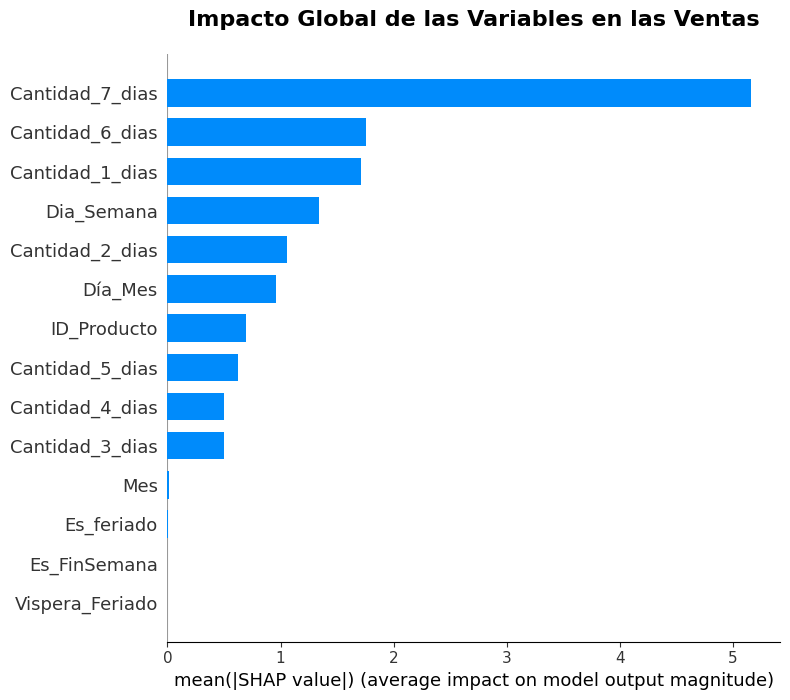

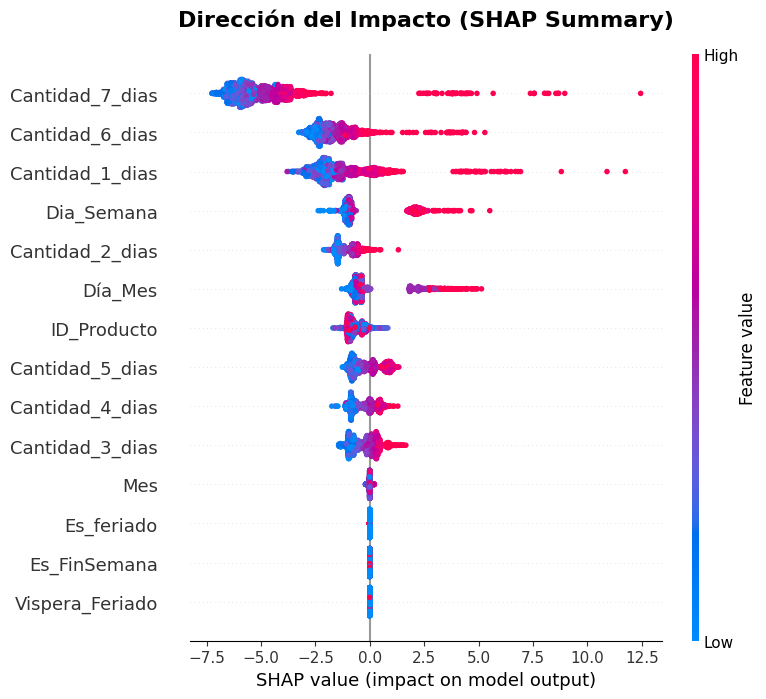

In [48]:
# Gráfico de Importancia Global (Resumen de Impacto)
plt.figure(figsize=(10, 6))
plt.title("Impacto Global de las Variables en las Ventas", fontsize=16, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Gráfico de Abeja (Muestra direcciones: ¿Un valor alto en 'Es_FinSemana' sube o baja la venta?)
plt.figure(figsize=(10, 6))
plt.title("Dirección del Impacto (SHAP Summary)", fontsize=16, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.show()

## Valores SHAP para una predicción especifica

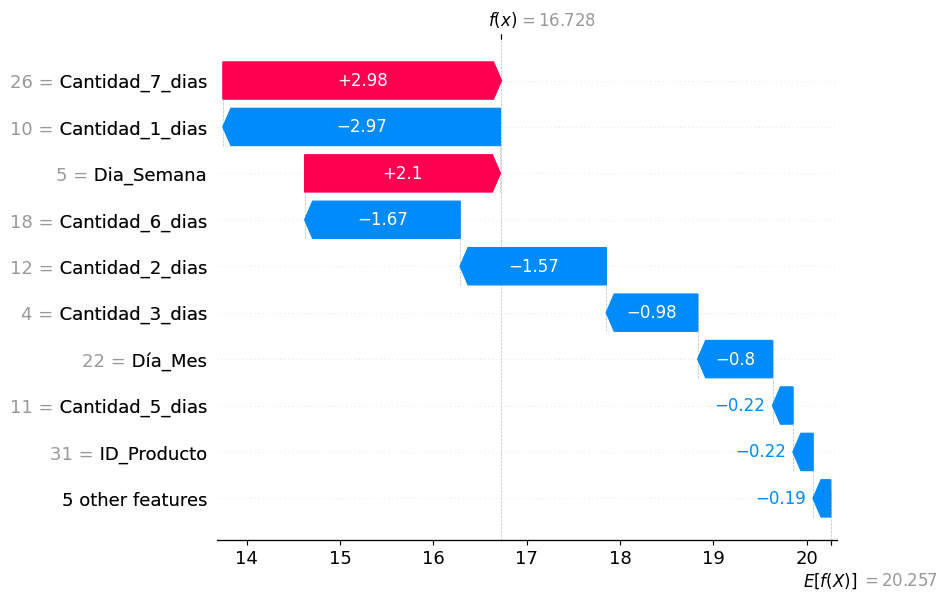

In [49]:
scaler = joblib.load('../models/scaler.pkl')
X_test_r=scaler.inverse_transform(X_test_scaled)
X_test_df = pd.DataFrame(X_test_r, columns=X_test_scaled.columns).round(0).astype(int)
# Elegir una predicción específica para explicar 
indice_prediccion = 5
producto_id = int(X_test_scaled.iloc[indice_prediccion]['ID_Producto'])

# Gráfico de cascada (Waterfall)
explicacion_local = shap.Explanation(
    values = shap_values[indice_prediccion].values,       # El impacto matemático del XGBoost (No se toca)
    base_values = shap_values[indice_prediccion].base_values, # El promedio base (No se toca)
    data = X_test_df.iloc[indice_prediccion].values, # Los datos reales des-escalados (¡Lo que queremos ver!)
    feature_names = X_test_df.columns.tolist()            # Nombres de las variables
)
shap.plots.waterfall(explicacion_local, max_display=10)

## Extracción de datos para el LLM

In [50]:
# Paso 6: Extracción de justificaciones para el LLM
import pandas as pd

valor_base = explicacion_local.base_values
prediccion_final = explicacion_local.values.sum() + valor_base

impactos_local = pd.DataFrame({
    'Variable': X_test_df.columns, 
    'Valor_Original': explicacion_local.data,
    'Impacto_en_Unidades_SHAP': explicacion_local.values
})

# Extracción dinámica de la variable
producto_id_real = int(impactos_local.loc[impactos_local['Variable'] == 'ID_Producto', 'Valor_Original'].values[0])

impactos_local['Magnitud_Absoluta'] = impactos_local['Impacto_en_Unidades_SHAP'].abs()
top_3_explicacion = impactos_local.sort_values(by='Magnitud_Absoluta', ascending=False).head(3)

print("--- Datos extraídos ---")
print(f"Producto ID: {producto_id_real}")
print(f"Predicción final del modelo: {prediccion_final:.0f} unidades")
print("\nTop 3 motivos de esta decisión:")
print(top_3_explicacion[['Variable', 'Valor_Original', 'Impacto_en_Unidades_SHAP']])

--- Datos extraídos ---
Producto ID: 31
Predicción final del modelo: 17 unidades

Top 3 motivos de esta decisión:
           Variable  Valor_Original  Impacto_en_Unidades_SHAP
7   Cantidad_7_dias              26                  2.984750
1   Cantidad_1_dias              10                 -2.972646
10       Dia_Semana               5                  2.096325


### Generación del prompt para el LLM

In [51]:
#Justificación para LLm
print("Actúa como un analista de ventas senior.")
print(f"Nuestro modelo de XGBOOST ha predicho una demanda de {prediccion_final:.0f} unidades para el Producto ID {producto_id_real}.")
print("Matematicamente, las 3 variables que más impulsaron esta prediccion fueron:")
for index, row in top_3_explicacion.iterrows():
    print(f"- {row['Variable']} con un valor de {row['Valor_Original']} impactó en {row['Impacto_en_Unidades_SHAP']:.2f} unidades.")
print(("Redacta una breve justificacion de negocio explicando en un maximo de 5 lineas a la gerencia el por qué se espera este nivel de ventas para este dia específico, omite jerfa técnica y enfocate en el negocio."))

Actúa como un analista de ventas senior.
Nuestro modelo de XGBOOST ha predicho una demanda de 17 unidades para el Producto ID 31.
Matematicamente, las 3 variables que más impulsaron esta prediccion fueron:
- Cantidad_7_dias con un valor de 26 impactó en 2.98 unidades.
- Cantidad_1_dias con un valor de 10 impactó en -2.97 unidades.
- Dia_Semana con un valor de 5 impactó en 2.10 unidades.
Redacta una breve justificacion de negocio explicando en un maximo de 5 lineas a la gerencia el por qué se espera este nivel de ventas para este dia específico, omite jerfa técnica y enfocate en el negocio.


- Respuesta generada por el LLM (Chat GPT) para el producto ID:31 (Galletas de agua)

Se espera una demanda de 17 unidades para el Producto ID 31 debido al fuerte nivel de ventas acumulado en la última semana, lo que refleja una tendencia de consumo sostenida. Aunque el día anterior presentó una desaceleración puntual, el comportamiento histórico indica que este tipo de caída suele recuperarse rápidamente. Además, el día de la semana favorece un mayor flujo de ventas para este producto, reforzando la expectativa de una demanda superior al promedio para esta fecha específica.